# Four-feature, all-speaker geometry baseline
F1, F2, F3 and duration only: no F0-based filtering or missingness feature. All 98 speakers and all 447,265 tokens. The four views and settings match the five-feature baseline. This is descriptive geometry, not held-out predictive evaluation. Change config_four.py, then set RESUME=None to launch a new run. Preprocessing is fitted to all observations for this descriptive analysis only.

In [1]:
from pathlib import Path
import sys, runpy, subprocess, json
import numpy as np
import pandas as pd
from IPython.display import display, Image
ROOT = Path.cwd().parents[1] if Path.cwd().name == 'vowel_geometry' else Path.cwd()
assert (ROOT/'metadata_vowels_acoustics.csv').exists()
sys.path.insert(0, str(ROOT))
CONFIG_PATH = ROOT/'lab_projects/vowel_geometry/config_four.py'
RESUME = ROOT/'lab_projects/vowel_geometry/results_four/20260929_230640'
OLD_RUN = ROOT/'lab_projects/vowel_geometry/results/20260929_173507'
display(runpy.run_path(str(CONFIG_PATH))['CONFIG'])
print('Interpreter:', sys.executable)


{'csv_path': 'metadata_vowels_acoustics.csv',
 'features': ['f1_hz', 'f2_hz', 'f3_hz', 'duration_s'],
 'seeds': [42, 43, 44],
 'fit_sample_seed': 2026,
 'fit_sample_max': 50000,
 'query_large': 1500,
 'query_small': 300,
 'large_group_threshold': 10000,
 'distance_chunk': 32,
 'kmeans_n_init': 10,
 'kmeans_max_iter': 300,
 'kmeans_tol': 0.0001,
 'workers': 2,
 'threads': 1,
 'output_dir': 'lab_projects/vowel_geometry/results_four'}

Interpreter: C:\Users\46021\.conda\envs\lffl\python.exe


In [2]:
command = [sys.executable, str(ROOT/'lab_projects/vowel_geometry/analyze.py'), '--config', str(CONFIG_PATH)]
if RESUME is not None: command += ['--resume', str(RESUME)]
result = subprocess.run(command, cwd=ROOT, capture_output=True, text=True, check=True)
print(result.stdout)
RUN = Path(result.stdout.split('COMPLETE:')[-1].strip())


COMPLETE: E:\SynologyDrive\Documents\research\variation_perceptual_magnet\codes\lab_projects\vowel_geometry\results_four\20260929_230640



REPORT: E:\SynologyDrive\Documents\research\variation_perceptual_magnet\codes\lab_projects\vowel_geometry\results_four\20260929_230640\REPORT.html


metric,ami,ari,completeness,homogeneity,kmeans_calinski_harabasz,kmeans_davies_bouldin,kmeans_silhouette,nmi,purity,shuffled_silhouette,silhouette_above_shuffle,truth_between_fraction,truth_calinski_harabasz,truth_davies_bouldin,truth_negative_fraction,truth_silhouette
view,,,,,,,,,,,,,,,,
phoneme_given_speaker,0.372110,0.336675,0.385153,0.361841,1847.086961,1.080080,0.305360,0.372830,0.569272,-0.013478,0.132435,0.331579,594.618724,2.680629,0.276032,0.118957
phoneme_pooled,0.217713,0.180326,0.219617,0.215859,136994.791495,1.225629,0.241058,0.217722,0.487772,-0.001313,0.047647,0.252824,37835.079866,2.883553,0.353556,0.046334
speaker_given_phoneme,0.171322,0.022850,0.185223,0.178602,10717.446697,1.205109,0.172286,0.181849,0.080958,-0.037497,-0.163837,0.159411,186.688335,15.866197,0.939244,-0.201334
speaker_pooled,0.100501,0.010521,0.104092,0.101151,44131.517225,1.212090,0.176165,0.102600,0.046840,-0.014289,-0.135367,0.080102,401.421539,26.104338,0.969556,-0.149656


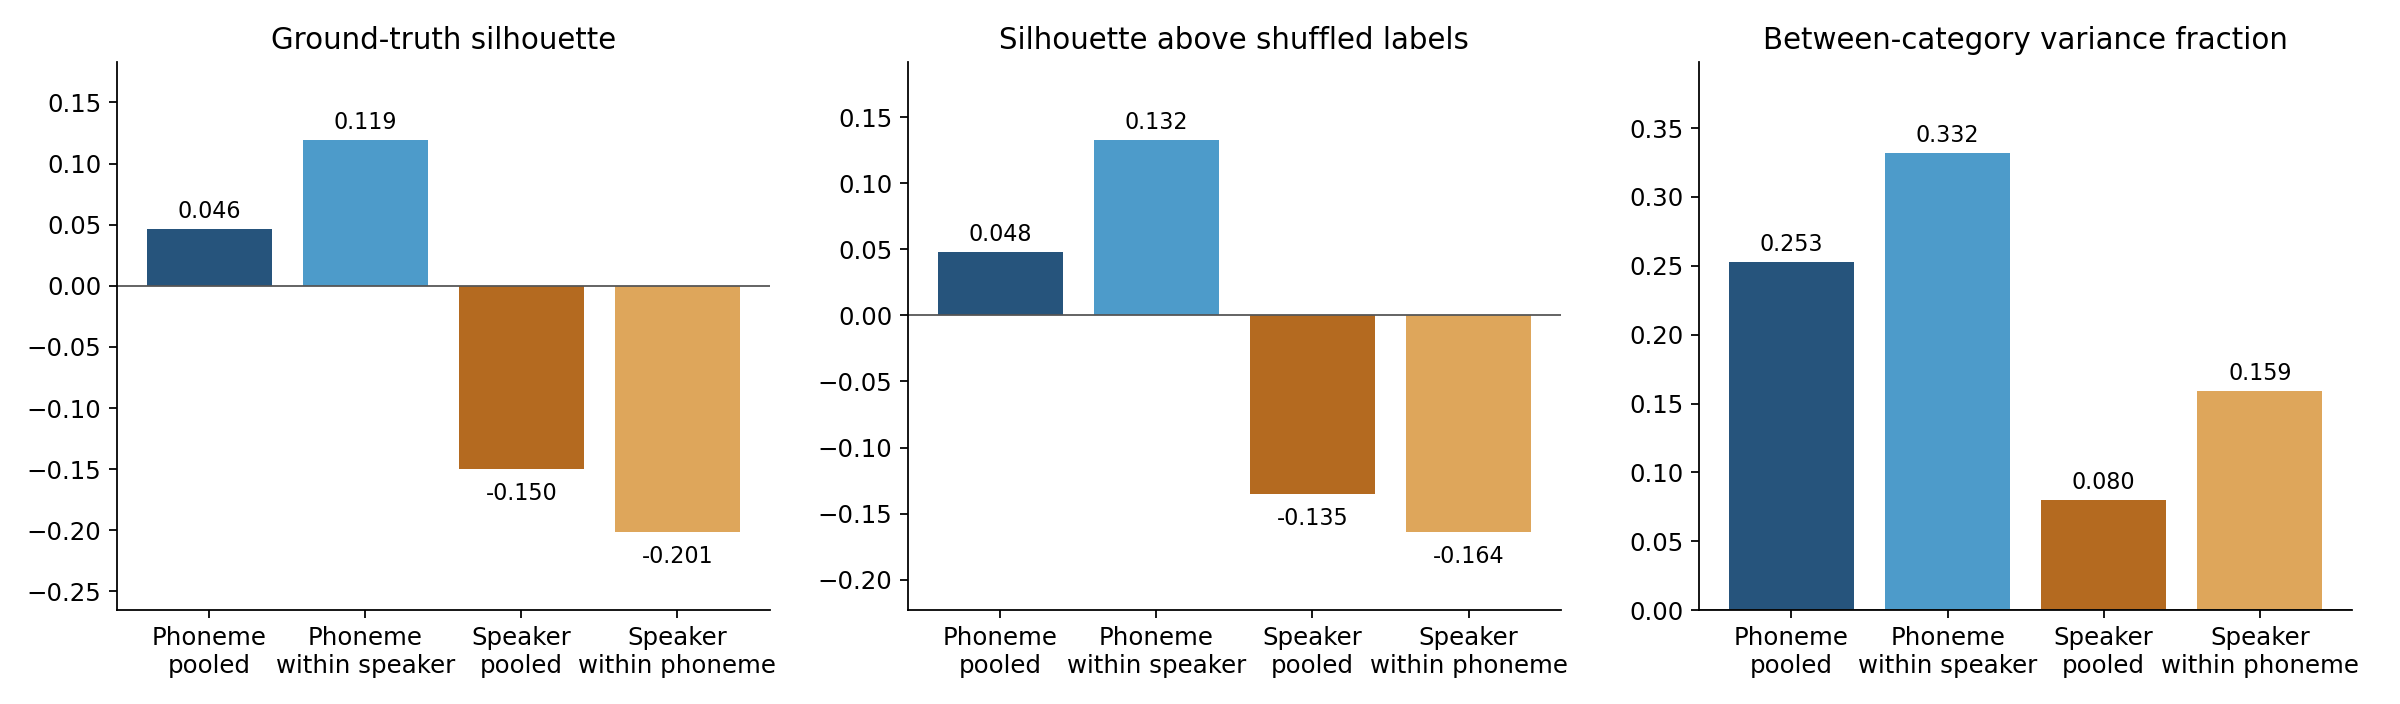

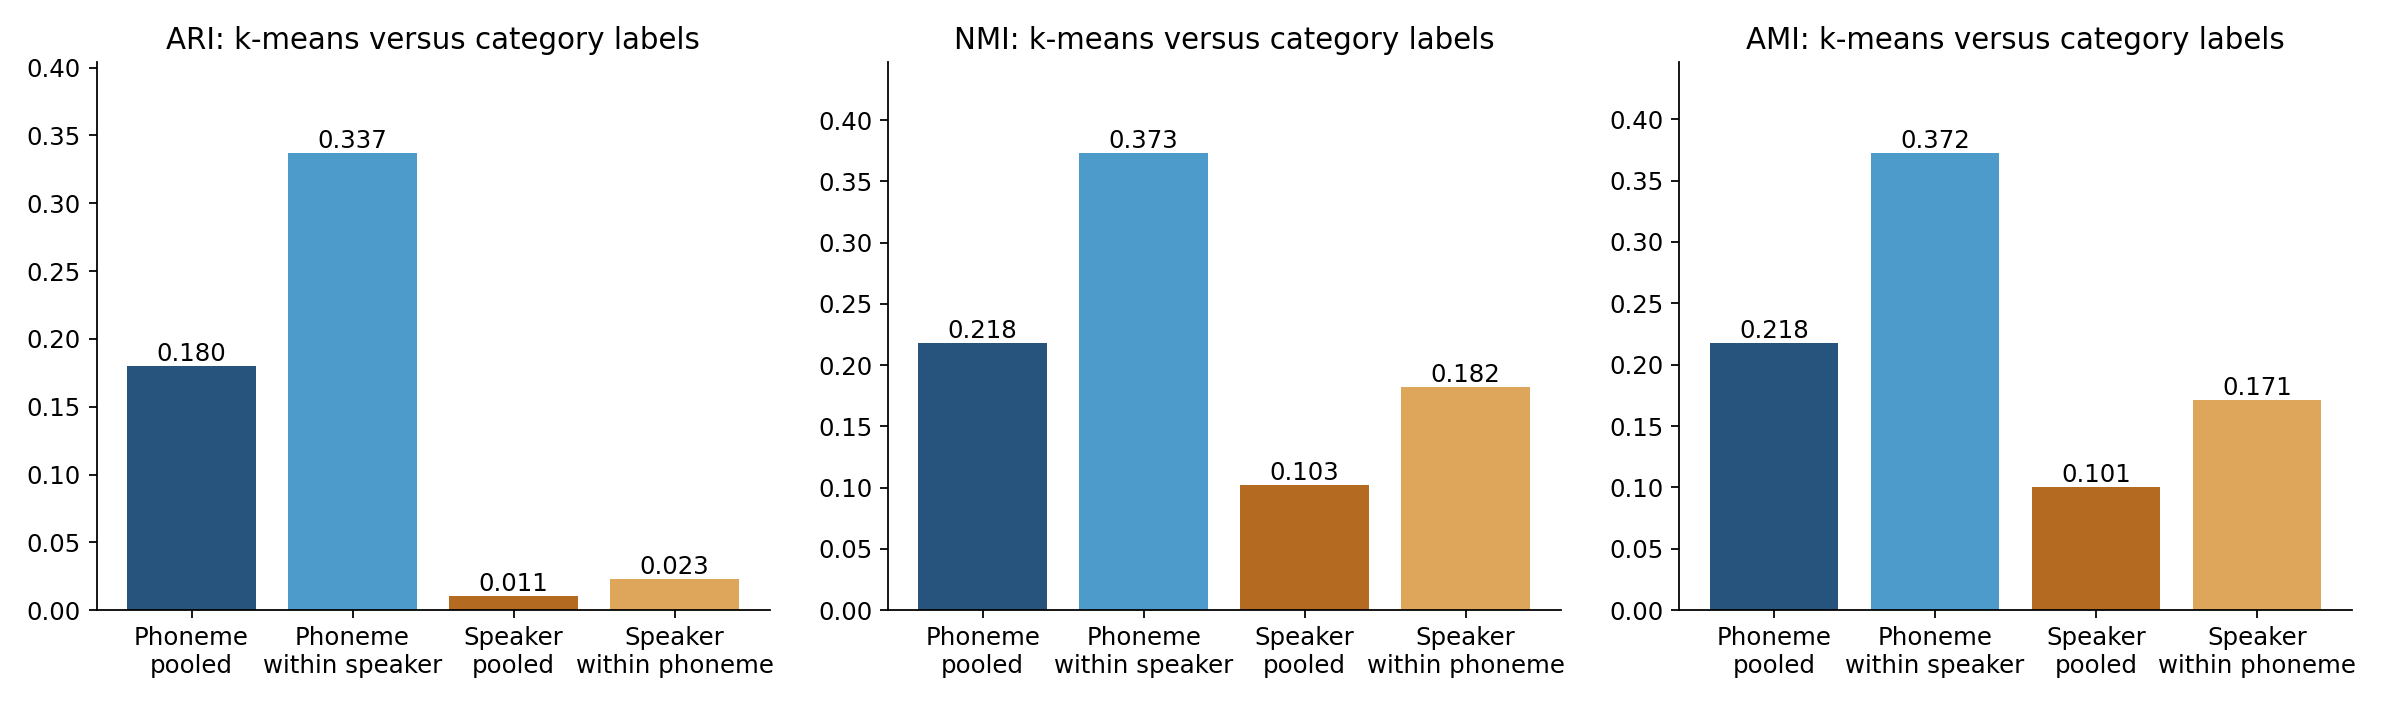

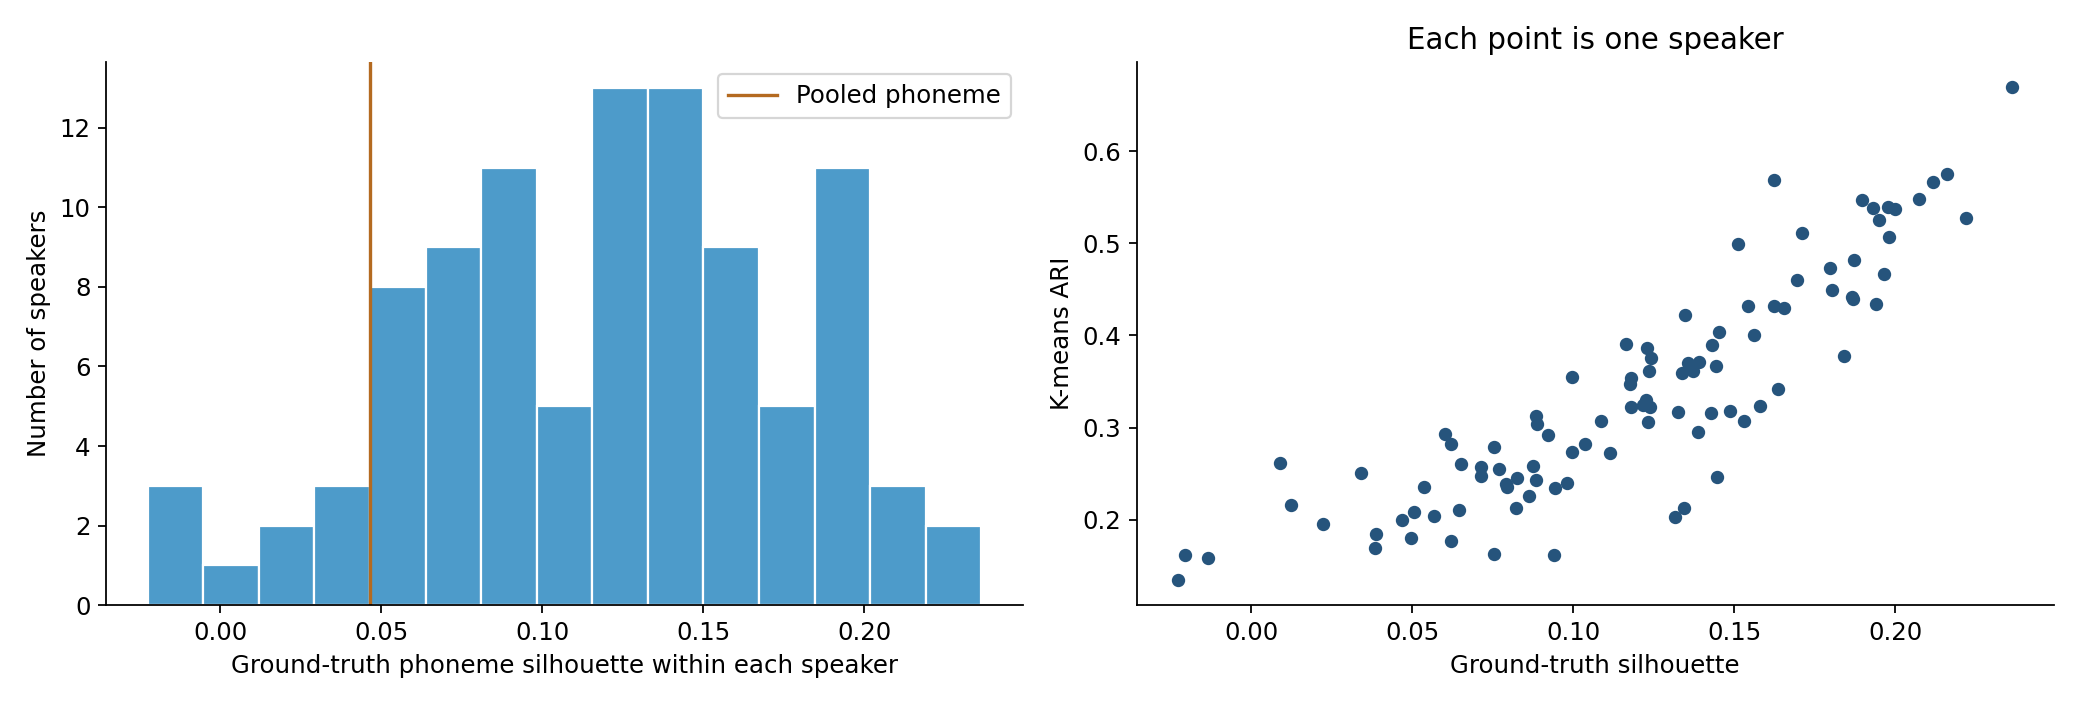

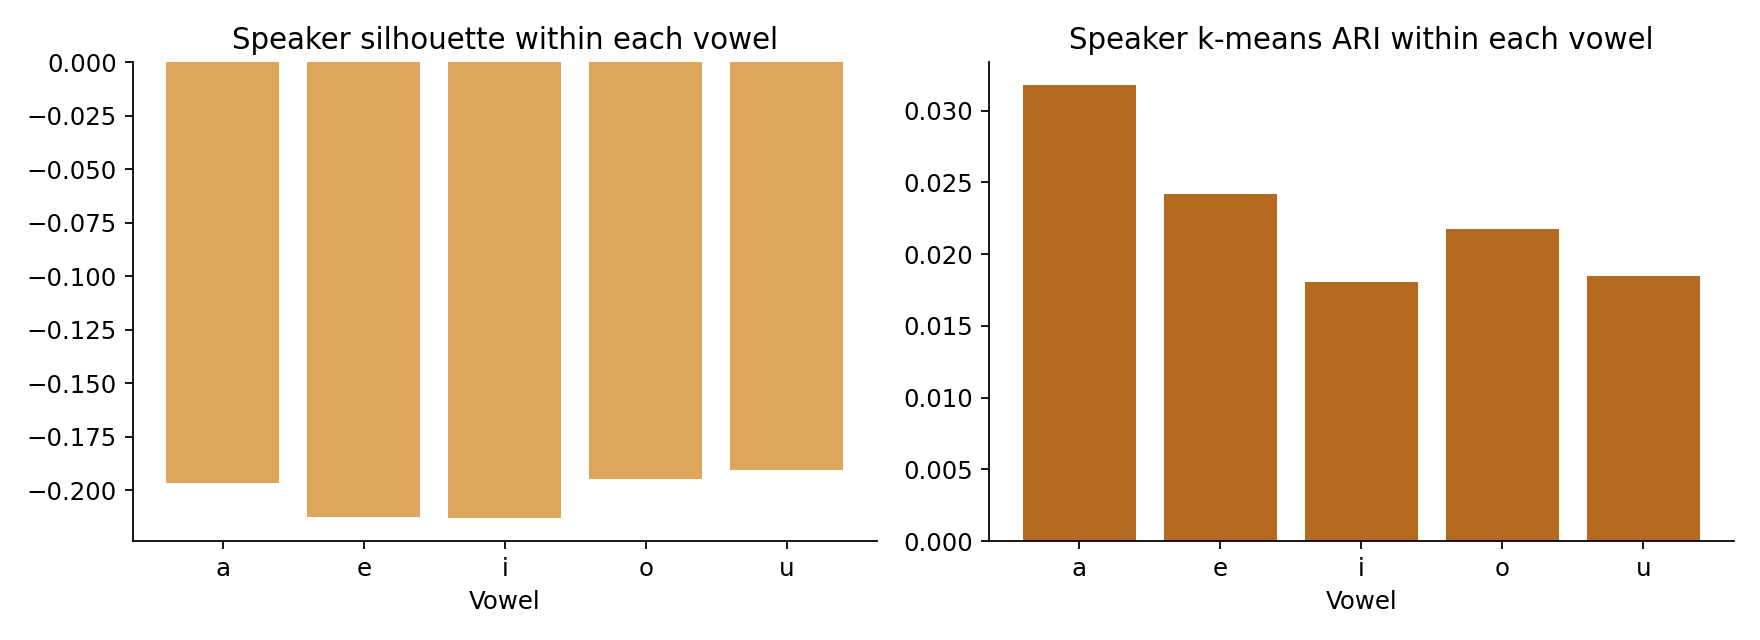

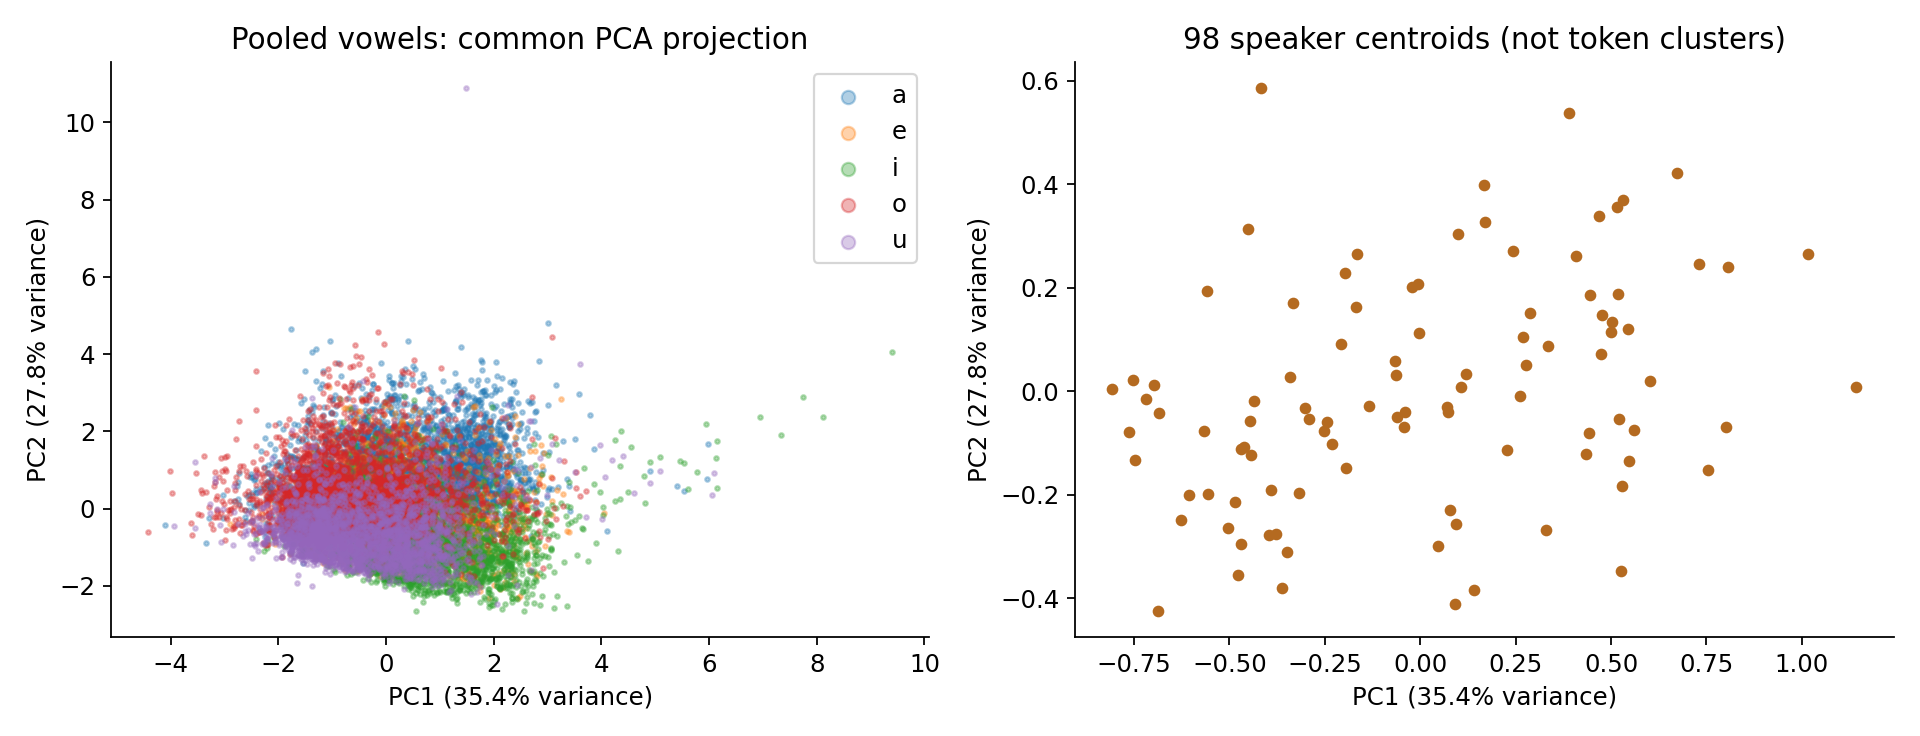

In [3]:
from lab_projects.vowel_geometry.report import make_report
make_report(RUN)
summary = pd.read_csv(RUN/'summary.csv')
display(summary[summary.weighting.eq('macro')].pivot(index='view', columns='metric', values='mean'))
for name in ['ground_truth', 'cluster_agreement', 'speaker_variation', 'phoneme_variation', 'pca']:
    display(Image(filename=str(RUN/'figures'/f'{name}.png')))


In [4]:
from lab_projects.vowel_geometry.compare_features import compare
comparison = compare(OLD_RUN, RUN)
display(comparison[comparison.metric.isin(['truth_silhouette','ari','nmi','ami'])])
metrics = pd.read_csv(RUN/'metrics.csv')
assert len(metrics) == 315 and metrics.seed.nunique() == 3
assert (metrics.groupby('view').n.sum() == 447265*3).all()
assert np.load(RUN/'standardized.npy').shape == (447265,4)
assert not metrics.fit_hit_max_iter.any()
print('Matched-design checks passed. Reports:', RUN/'REPORT.html', RUN/'COMPARISON.html')


                 view           metric  five_features  four_features  delta_four_minus_five  paired_repeat_sd
       phoneme_pooled truth_silhouette       0.030438       0.046334               0.015895          0.000819
       phoneme_pooled              ari       0.126135       0.180326               0.054191          0.000301
       phoneme_pooled              nmi       0.164941       0.217722               0.052780          0.000084
       phoneme_pooled              ami       0.164932       0.217713               0.052781          0.000084
phoneme_given_speaker truth_silhouette       0.089455       0.118957               0.029502          0.000716
phoneme_given_speaker              ari       0.285419       0.336675               0.051256          0.001866
phoneme_given_speaker              nmi       0.330370       0.372830               0.042460          0.001550
phoneme_given_speaker              ami       0.329605       0.372110               0.042505          0.001551
       spe

,view,metric,five_features,four_features,delta_four_minus_five,paired_repeat_sd
0,phoneme_pooled,truth_silhouette,0.030438,0.046334,0.015895,0.000819
10,phoneme_pooled,ari,0.126135,0.180326,0.054191,0.000301
11,phoneme_pooled,nmi,0.164941,0.217722,0.052780,0.000084
12,phoneme_pooled,ami,0.164932,0.217713,0.052781,0.000084
16,phoneme_given_speaker,truth_silhouette,0.089455,0.118957,0.029502,0.000716
26,phoneme_given_speaker,ari,0.285419,0.336675,0.051256,0.001866
27,phoneme_given_speaker,nmi,0.330370,0.372830,0.042460,0.001550
28,phoneme_given_speaker,ami,0.329605,0.372110,0.042505,0.001551
32,speaker_pooled,truth_silhouette,-0.131667,-0.149656,-0.017988,0.001575
42,speaker_pooled,ari,0.012138,0.010521,-0.001617,0.000181


Matched-design checks passed. Reports: E:\SynologyDrive\Documents\research\variation_perceptual_magnet\codes\lab_projects\vowel_geometry\results_four\20260929_230640\REPORT.html E:\SynologyDrive\Documents\research\variation_perceptual_magnet\codes\lab_projects\vowel_geometry\results_four\20260929_230640\COMPARISON.html
